For validation of sensors. 
This notebook try to use the NI visa driver to communicate with a Rigol dp832 programmable dc power supply, 
And collect information on sensors from a DM 3058E digital multimeter. 

Communicaiton is conducted through the SCPI protocol using pyVisa 


the ones I have access to only have APPL and no additional DP8-OPTION license
Most commands will not work
Amendment: This was because the firmware was out of date. After accepting updated firmware from manufacturer, was able to establish communication correctly with DMM 

In [1]:
!pip install pyVisa



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [123]:
# print available instruments, should see something like dp8c172002060
# or DM3R171500547 for multimeter
import pyvisa

rm = pyvisa.ResourceManager()
print(rm.list_resources())

DMM = "USB0::0x1AB1::0x09C4::DM3R171500547::INSTR"
PSU = "USB0::0x1AB1::0x0E11::DP8C172002060::INSTR"

('USB0::0x1AB1::0x0E11::DP8C172002060::INSTR', 'USB0::0x1AB1::0x09C4::DM3R171500547::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'ASRL8::INSTR', 'ASRL11::INSTR', 'ASRL12::INSTR')


PSU automation helpers 

In [124]:
import pyvisa
import time

def set_psu_rail(resource_addr, channel = 1, volt = 0, curr = 0):
    rm = pyvisa.ResourceManager()
    psu = rm.open_resource(resource_addr)

    # Identify instrument
    print("ID:", psu.query("*IDN?").strip())

    # Select CH1
    psu.write(f":INST:NSEL {channel}")

    # Set source: 1 V, 10 mA
    psu.write(f":SOUR:VOLT {volt}")
    psu.write(f":SOUR:CURR {curr}")

    # brief wait
    time.sleep(0.5) #wait at least 0.5s 

    # Query output readings
    voltage = psu.query(":MEAS:VOLT?").strip()
    current = psu.query(":MEAS:CURR?").strip()

    print(f"Measured: V={voltage}  I={current}")

    psu.close()

def toggle_psu_rail(resource_addr, channel = 1, toggle = "OFF"):
    rm = pyvisa.ResourceManager()
    psu = rm.open_resource(resource_addr)

    # Identify instrument
    print("ID:", psu.query("*IDN?").strip())

    # Select CH1
    psu.write(f":INST:NSEL {channel}")

    # toggle channel
    psu.write(f":OUTP {toggle}")

    # brief wait
    time.sleep(0.5) #wait at least 0.5s 

    # Query output readings
    voltage = psu.query(":MEAS:VOLT?").strip()
    current = psu.query(":MEAS:CURR?").strip()

    print(f"Measured: V={voltage}  I={current}")

    psu.close()




In [ ]:
set_psu_rail(PSU, 1, 1, 0.25)
toggle_psu_rail(PSU, 1, "ON")
toggle_psu_rail(PSU, 1, "OFF")

DMM AUTOMATION helpers below

In [125]:
# send ARBITRARY COMMAND 
def cmd(resource_addr, cmd):
    rm = pyvisa.ResourceManager()
    machine = rm.open_resource(resource_addr)

    print("ID:", machine.query("*IDN?").strip())

    print(cmd)
    machine.query(cmd)
    print(machine.query(":SYST:ERR?"))      
    
    return



In [126]:
def set_dmm_mode(resource_addr, mode_str):
    """
    Set DM3058/DM3058E measurement mode.

    Parameters
    ----------
    resource_addr : str
        VISA resource string
    mode_str : str
        SCPI mode string, e.g.
        "VOLT:DC", "VOLT:AC",
        "CURR:DC", "CURR:AC",
        "RES", "FRES", "DIOD", "CONT"

    Returns
    -------
    new_mode : str
        The confirmed active mode after setting
    """

    rm = pyvisa.ResourceManager()
    dmm = rm.open_resource(resource_addr)

    # Identify
    print("ID:", dmm.query("*IDN?").strip())

    # Read old mode
    old_mode = dmm.query(":FUNC?").strip()
    print("Old mode:", old_mode)

    # Set mode
    dmm.write(f":MEAS:{mode_str}?") # MEAS COMMAND with a NEW MODE will force DMM into a new mode. Bypass some issues.
    time.sleep(0.5)
    value = dmm.query(f":MEAS:{mode_str}?").strip()
    print(value)

    # Query new mode 
    print(dmm.query(":SYST:ERR?")) # THIS LINE MUST EXIST OR NEW MODE WILL NOT BE READ
    new_mode = dmm.query(":FUNC?").strip()
    print("New mode:", new_mode)

    dmm.close()
    return new_mode


set_dmm_mode(DMM, "CURR:DC")

ID: Rigol Technologies,DM3058E,DM3R171500547,01.01.00.02.03.01
Old mode: DCV
9.294274E-10
-410,"Query INTERRUPTED"

New mode: DCI


'DCI'

In [127]:
def measure(resource_addr, mode): 
    print("measuring")
        #     SCPI mode string, e.g.
        # "VOLT:DC", "VOLT:AC",
        # "CURR:DC", "CURR:AC",
        # "RES", "FRES", "DIOD", "CONT"
    rm = pyvisa.ResourceManager()
    dmm = rm.open_resource(resource_addr)

    # Force measurement in chosen mode
    meas_cmd = f":MEAS:{mode}?"
    raw = dmm.query(meas_cmd).strip()

    # Return float value
    try:
        val = float(raw)
    except:
        val = raw   # fall back to string if non-numeric (e.g., OPEN)
        print(val)

    dmm.close()
    return val

In [128]:
def find_arrays_in_order(data, query):
    results = []
    for arr in data:
        it = iter(arr)
        if all(item in it for item in query):
            results.append(arr)
    return results

validation measurements: 
Define two arbitrary voltage and current ceiling and number of steps. 

Script: increase PSU steps from 0 to defined number
        Poll measurement at some arbitrary interval for both voltage and amp. 
        
Signal: create a signal to identify when the observations start for aligning timestamps probably just gonna make it jump three times 

In [173]:
import os
import re

os.chdir("C:/Users/andyh/Downloads/serialreceive/validation/dmm")

rm = pyvisa.ResourceManager()
PSU
DMM 

experiment_rail = 1
fetcher_rail = 2

experiment_max_volt = 12
experiment_max_amp = 3

experiment_duration = 10 # seconds

experiment_steps = 10 # how many steps do we expect power to increase by 

freq_hz = 10

def init ():
    global rm 
    global PSU
    global DMM
    rm = pyvisa.ResourceManager()
    PSU = find_arrays_in_order(rm.list_resources(), "DP")[0]
    DMM = find_arrays_in_order(rm.list_resources(), "DM")[0]
    print (PSU)
    print(DMM)

    print("turn on fetcher")
    set_psu_rail(PSU, fetcher_rail, volt =5, curr = 0.25)
    toggle_psu_rail(PSU, fetcher_rail, "ON")
    time.sleep(10) # it take a bit to turn on 

    return

def signal (): # make DP make a cliff for 3 times to signal begin of experiment.
    print("signaling")
    set_psu_rail(PSU, channel=experiment_rail, volt = experiment_max_volt, curr = experiment_max_amp)
    toggle_psu_rail(PSU, experiment_rail, "ON")
    time.sleep(2)
    toggle_psu_rail(PSU, experiment_rail, "OFF")
    time.sleep(1)
    toggle_psu_rail(PSU, experiment_rail, "ON")
    time.sleep(2)
    toggle_psu_rail(PSU, experiment_rail, "OFF")
    time.sleep(1)
    toggle_psu_rail(PSU, experiment_rail, "ON")
    time.sleep(2)
    toggle_psu_rail(PSU, experiment_rail, "OFF")
    time.sleep(1)
    set_psu_rail(PSU, channel=experiment_rail, volt = 0, curr = 0)
    return

#since INA226 compute power with vbus and curr anyways, it is simply neccessary to 

import time
import numpy as np
import pandas as pd
from datetime import datetime
import math

def experiment(min_v, max_v, min_a, max_a, duration, steps, freq=1, metric = "VOLT:DC"):

    starttime = time.time()
    #signal()
    
    
    set_psu_rail(PSU, channel=experiment_rail, volt = min_v, curr = min_a)
    toggle_psu_rail(PSU, experiment_rail, "ON")

    set_dmm_mode(DMM, mode_str = metric)

    measurements = np.zeros((int(math.ceil(duration*freq)) + 5, 2), dtype="float")
    index = 0
    steps_done = 0
    step_size_v = max_v / steps
    step_size_a = max_a / steps


    # Each entry = (task_name, interval_seconds)
    tasks = [
        ("measure", 1.0 / freq),
        ("ramp", duration / steps),
        ("heartbeat", 10.0),
    ]

    now = time.time()
    end = now + duration

    # precompute next timestamps
    task_next = [now + interval for (_, interval) in tasks]

    while True:
        now = time.time()
        if now >= end:
            break

        for i, (task_name, interval) in enumerate(tasks):
            if now >= task_next[i]:

                # --- dispatch based on task name ---
                if task_name == "measure":
                    val = measure(DMM, metric)
                    timestamp = time.time() - starttime
                    measurements[index, 0] = timestamp
                    measurements[index, 1] = val
                    index += 1
                    

                elif task_name == "ramp":
                    steps_done += 1
                    if (steps_done > steps): 
                        print("output is max")
                    else: 
                        print("Increasing output")
                        set_psu_rail(PSU, experiment_rail, volt= steps_done*step_size_v, curr= steps_done*step_size_a)

                elif task_name == "heartbeat":
                    print(f"[{time.time():.3f}] heartbeat")

                else:
                    print("Unknown task:", task_name)

                # schedule next event
                task_next[i] += interval

        time.sleep(0.001)

    print(f"Done, saving to {os.getcwd()}")
    print(measurements)
    filename = f"{starttime}_dmm_{re.sub(r'[^A-Za-z0-9]', '',metric)}"
    np.save(f"{filename}.npy", measurements)
    np.savetxt(f"{filename}.csv", measurements, delimiter=",")

    toggle_psu_rail(PSU, experiment_rail, "OFF")
    set_psu_rail(PSU, experiment_rail, volt =0, curr = 0)
    return measurements



def test_curr():
    return

In [153]:
init()

USB0::0x1AB1::0x0E11::DP8C172002060::INSTR
USB0::0x1AB1::0x09C4::DM3R171500547::INSTR
turn on fetcher
ID: RIGOL TECHNOLOGIES,DP832,DP8C172002060,00.01.19
Measured: V=0.00  I=0.000
ID: RIGOL TECHNOLOGIES,DP832,DP8C172002060,00.01.19
Measured: V=5.00  I=0.047


In [174]:


dmm_data = experiment(min_v = 0, max_v = experiment_max_volt, min_a= 0, max_a = experiment_max_amp, duration=100, steps = 10, freq= 1, metric = "CURR:DC")

ID: RIGOL TECHNOLOGIES,DP832,DP8C172002060,00.01.19
Measured: V=0.00  I=0.000
ID: RIGOL TECHNOLOGIES,DP832,DP8C172002060,00.01.19
Measured: V=0.00  I=0.000
ID: Rigol Technologies,DM3058E,DM3R171500547,01.01.00.02.03.01
Old mode: DCI
-5.619021E-05
-410,"Query INTERRUPTED"

New mode: DCI
measuring
measuring
measuring
measuring
measuring
measuring
measuring
measuring
measuring
measuring
Increasing output
ID: RIGOL TECHNOLOGIES,DP832,DP8C172002060,00.01.19
Measured: V=1.20  I=0.005
[1762973336.343] heartbeat
measuring
measuring
measuring
measuring
measuring
measuring
measuring
measuring
measuring
measuring
Increasing output
ID: RIGOL TECHNOLOGIES,DP832,DP8C172002060,00.01.19
Measured: V=2.40  I=0.096
[1762973346.495] heartbeat
measuring
measuring
measuring
measuring
measuring
measuring
measuring
measuring
measuring
measuring
Increasing output
ID: RIGOL TECHNOLOGIES,DP832,DP8C172002060,00.01.19
Measured: V=2.40  I=0.145
[1762973356.657] heartbeat
measuring
measuring
measuring
measuring
meas

       timestamp          A     
0    72875766333  29.985630  0.0
1    73875768500   0.000458  0.0
2    74875768833   0.000458  0.0
3    75875770375   0.000458  0.0
4    76875771250  29.985172  0.0
..           ...        ...  ...
85  157875872750   0.407678  0.0
86  158875873375   0.406306  0.0
87  159875874458   0.407221  0.0
88  160875874958   0.407221  0.0
89  161875876667   0.405848  0.0

[90 rows x 3 columns]
      timestamp         A     
12  84875784208  0.004576  0.0
13  85875785500  0.048500  0.0
14  86875787000  0.049416  0.0
15  87875787250  0.048500  0.0
16  88875787375  0.048958  0.0
17  89875788542  0.048958  0.0
18  90875790917  0.048500  0.0
19  91875791333  0.048958  0.0
20  92875792333  0.047128  0.0
21  93875793292  0.048500  0.0
[]
(90, 3)
[]


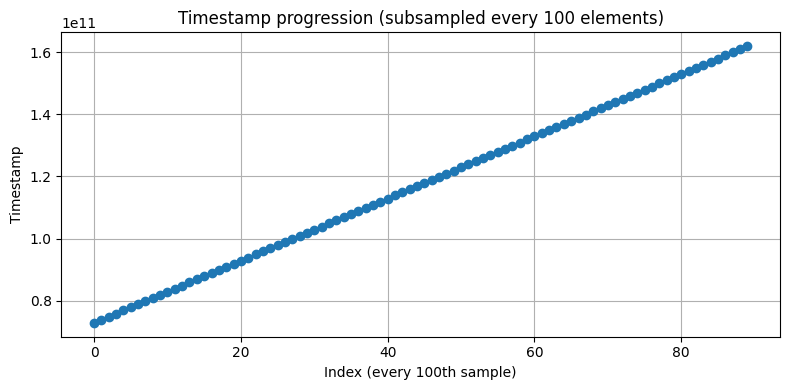

Index(['timestamp', 'A', ' '], dtype='object')
Index(['timestamp', 'value'], dtype='object')
(105, 2)
    timestamp     value  timestamp_s
10  13.622734  0.048274    10.189136
11  14.105808  0.048274    10.672210
12  15.072066  0.048274    11.638468
13  16.038411  0.048275    12.604813
14  17.487204  0.048275    14.053606


C:\Users\andyh\AppData\Local\Temp\ipykernel_6812\1124815637.py:198: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[out_col] = (df[col] - t0).astype("float64") / 1e9


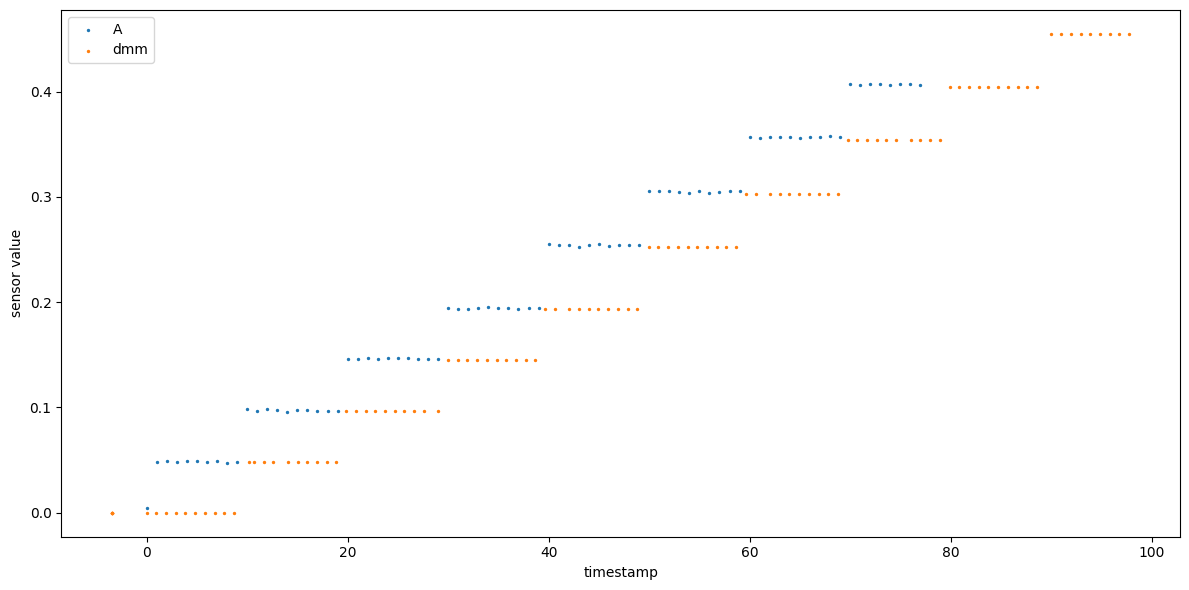

In [178]:
# display and process data
import os
import struct
import pandas as pd
import numpy as np

def parse_payload(payload: bytes):
    # payload = 4B header + 8B timestamp + 70B data (14×5B entries)
    timestamp = struct.unpack('<Q', payload[4:12])[0]
    entries = payload[12:]
    data_dict = {}
    for i in range(0, len(entries), 5):
        char_id = chr(entries[i])
        value = struct.unpack('<f', entries[i+1:i+5])[0]
        data_dict[char_id] = value
    return timestamp, data_dict

def parse_binary_folder(folder_path: str):
    # 4-byte discard field, then 8-byte timestamp, then 16 × (1-byte id + 4-byte float)
    record_dtype = np.dtype([
        ('_discard', '4u1'),                 # 4 bytes
        ('timestamp', '<u8'),                # 8 bytes (uint64)
        ('pairs', [('id', 'u1'), ('data', '<f4')], (16,))  # 16 × (1+4)
    ])
    record_size = record_dtype.itemsize  # should be 92 bytes

    files = sorted(
        [f for f in os.listdir(folder_path) if f.startswith('data') and f.endswith('.bin')],
        key=lambda x: int(x[4:-4])
    )

    timestamps_all = []
    id_arrays = {i: [] for i in range(16)}  # accumulate data columns by slot
    id_chars = None                         # to hold column names (char IDs)

    for filename in files:
        path = os.path.join(folder_path, filename)

        with open(path, 'rb') as f:
            data_bytes = f.read()  # read entire file (no header)
            n_records = len(data_bytes) // record_size
            if n_records == 0:
                continue

            # vectorized read
            arr = np.frombuffer(data_bytes, dtype=record_dtype, count=n_records)

            timestamps = arr['timestamp']
            ids = arr['pairs']['id']       # shape (n_records, 16)
            vals = arr['pairs']['data']    # shape (n_records, 16)

            timestamps_all.append(timestamps)

            # verify consistent IDs per column
            first_ids = ids[0, :]
            if not np.all(ids == first_ids):
                mismatched = np.nonzero(~np.all(ids == first_ids, axis=1))[0][:5]
                print(f"\n[DEBUG] ID mismatch in file {filename}: showing first {len(mismatched)} bad rows")
                print("Expected IDs (bytes):", " ".join(f"{b:02X}" for b in first_ids))
                for idx in mismatched:
                    raw_hex = " ".join(f"{b:02X}" for b in ids[idx])
                    print(f"  Row {idx:>6}: {raw_hex}")
                raise ValueError(f"File {filename} has mixed IDs per column!")

            # store char representations once (from first file)
            if id_chars is None:
                id_chars = [chr(x) for x in first_ids]

            # accumulate per-ID arrays
            for i, id_val in enumerate(first_ids):
                id_arrays[i].append(vals[:, i])

    if not timestamps_all:
        raise ValueError("No valid records found in folder!")

    # concatenate across files
    timestamps_all = np.concatenate(timestamps_all)
    data_cols = {}
    for i, chunks in id_arrays.items():
        if len(chunks) == 0:
            continue
        colname = id_chars[i] if id_chars is not None else f"id_{i}"
        data_cols[colname] = np.concatenate(chunks)

    # Build DataFrame
    df = pd.DataFrame(data_cols)
    df.insert(0, "timestamp", timestamps_all.astype(np.uint64))

    return df

def find_rollovers(df):
    if df['timestamp'].dtype != 'uint64':
        df['timestamp'] = df['timestamp'].astype('uint64')

    # Diff using int64 to preserve exact rollover detection
    diffs = df['timestamp'].astype('int64').diff()

    rollover_points = df.index[diffs < 0].tolist()

    for idx in rollover_points:
        t_before = df.loc[idx - 1, 'timestamp']
        t_after = df.loc[idx, 'timestamp']
        print(f"Timestamp rollover at index {idx}: {t_before} → {t_after}")

    return rollover_points

# Example usage:
df = parse_binary_folder('C:/Users/andyh/Downloads/serialreceive/trace2')
print(df.head(150))

print (df.iloc[12:75].head(10))

rollover = find_rollovers(df)
print(rollover)

print(df.shape)

# USE ONLY FOR ONLY TEENSY
import pandas as pd

def correct_timestamp_overflow(df: pd.DataFrame, time_col: str = "timestamp",
                               overflow_points=None, overflow_constant=None) -> pd.DataFrame:
    """
    Correct timestamp overflows by adding multiples of overflow_constant
    after each detected overflow point.

    Parameters:
        df (pd.DataFrame): Input DataFrame with timestamp column.
        time_col (str): Name of the timestamp column.
        overflow_points (list[int]): List of row indices where overflow occurs.
        overflow_constant (int): The value to add after each overflow (e.g. 2**32).
    
    Returns:
        pd.DataFrame: Copy of df with corrected timestamp column.
    """
    if overflow_points is None or overflow_constant is None:
        raise ValueError("Must provide overflow_points and overflow_constant")

    result_df = df.copy()
    corrected = result_df[time_col].astype("int64").copy()

    offset = 0
    current_overflow_idx = 0

    # Iterate over rows, adding offsets after each overflow point
    for i in range(len(corrected)):
        if (current_overflow_idx < len(overflow_points)
                and i >= overflow_points[current_overflow_idx]):
            # Passed an overflow point -> increase offset
            current_overflow_idx += 1
            offset += overflow_constant
        corrected.iloc[i] += offset

    result_df[time_col] = corrected
    return result_df

# Overflow constant for 32-bit counter converted to nanosecond
OVERFLOW_CONST = 2**32 * 125 / 3

corrected_df = correct_timestamp_overflow(df, overflow_points=rollover, overflow_constant=OVERFLOW_CONST)

#print(corrected_df.head(10))
testrollover= find_rollovers(corrected_df)
print(testrollover)
#print(corrected_df.iloc[120:135].head(10))
#print(df.iloc[120:135].head(10))
import matplotlib.pyplot as plt

ts_sub = corrected_df["timestamp"].iloc[::1].reset_index(drop=True)

# Plot timestamp vs index
plt.figure(figsize=(8, 4))
plt.plot(ts_sub.index, ts_sub, marker='o', linestyle='-', linewidth=1)

plt.xlabel("Index (every 100th sample)")
plt.ylabel("Timestamp")
plt.title("Timestamp progression (subsampled every 100 elements)")
plt.grid(True)
plt.tight_layout()
plt.show()

print(corrected_df.columns)
import matplotlib.pyplot as plt

def add_relative_timestamp_seconds(df: pd.DataFrame,
                                   col="timestamp",
                                   out_col="timestamp_s"):
    """
    Given a DataFrame with an int64 nanosecond timestamp column,
    add a 
      seconds-relative column using the first timestamp
    (or earliest timestamp) as t = 0.
    """
    # anchor = first non-NA timestamp
    t0 = df[col].iloc[0]

    # compute relative seconds
    df[out_col] = (df[col] - t0).astype("float64") / 1e9
    return df
corrected_df = add_relative_timestamp_seconds(corrected_df)
dmm_df = pd.DataFrame(dmm_data, columns = ["timestamp", "value"])
print(dmm_df.columns)
print(dmm_df.shape)
dmm_df['timestamp_s'] = (dmm_df['timestamp'] - dmm_df['timestamp'].iloc[0])

df29_sub = add_relative_timestamp_seconds(corrected_df.iloc[12:])

sensor_cols = ['A','B','C','D','H','I','J','K','Y','Z','O','P','Q','R','U','V']
sensor_cols = ['Y','B','D','H','I','J','K','O','U','V']
sensor_cols = ['A']

plt.figure(figsize=(12,6))

for col in sensor_cols:
    plt.scatter(df29_sub['timestamp_s'], df29_sub[col], label=col, s=2)
plt.scatter(dmm_df['timestamp_s'], dmm_df['value'], label = 'dmm', s=2)
print(dmm_df.iloc[10:30].head(5))

plt.xlabel("timestamp")
plt.ylabel("sensor value")
plt.legend()
plt.tight_layout()
plt.show()

Due to the fact that we can't easily make the dmms produce timestamp, synchronization of the data have to be performed manually for validation.
To only correct for constant clock offsets, we adjust the sensor timestamp by a constant value only. 

Timestamp rollover at index 122: 178732772875 → 32125
[122]
Timestamp rollover at index 122: 178732772875 → 32125
[]
Timestamp rollover at index 84: 178665220125 → 33458
[84]
Timestamp rollover at index 84: 178665220125 → 33458
[]
Timestamp rollover at index 38: 178771090042 → 34292
[38]
Timestamp rollover at index 38: 178771090042 → 34292
[]
[]
Timestamp rollover at index 83: 178723433625 → 33750
[83]
Timestamp rollover at index 83: 178723433625 → 33750
[]
[]
['C:\\Users\\andyh\\Downloads\\serialreceive\\validation\\dmm', 'C:\\Users\\andyh\\Downloads\\serialreceive\\validation\\sensor20', 'C:\\Users\\andyh\\Downloads\\serialreceive\\validation\\sensor20c', 'C:\\Users\\andyh\\Downloads\\serialreceive\\validation\\sensor21', 'C:\\Users\\andyh\\Downloads\\serialreceive\\validation\\sensor21c', 'C:\\Users\\andyh\\Downloads\\serialreceive\\validation\\sensor22', 'C:\\Users\\andyh\\Downloads\\serialreceive\\validation\\sensor22c', 'C:\\Users\\andyh\\Downloads\\serialreceive\\validation\\sen

C:\Users\andyh\AppData\Local\Temp\ipykernel_6812\1124815637.py:152: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '178957002791.66666' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  corrected.iloc[i] += offset
C:\Users\andyh\AppData\Local\Temp\ipykernel_6812\1124815637.py:152: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '178957004124.66666' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  corrected.iloc[i] += offset
C:\Users\andyh\AppData\Local\Temp\ipykernel_6812\1124815637.py:152: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '178957004958.66666' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  corrected.iloc[i] += offse

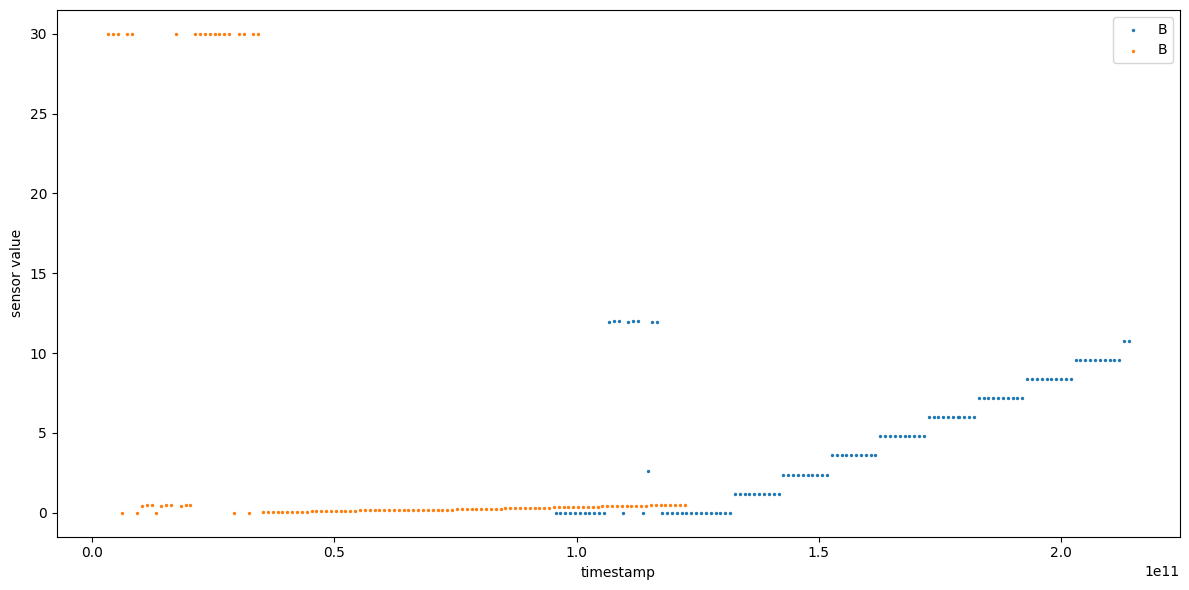

C:\Users\andyh\Downloads\serialreceive\validation\CUsersandyhDownloadsserialreceivevalidationsensor20.csv
C:\Users\andyh\Downloads\serialreceive\validation\CUsersandyhDownloadsserialreceivevalidationsensor20c.csv
C:\Users\andyh\Downloads\serialreceive\validation\CUsersandyhDownloadsserialreceivevalidationsensor21.csv
C:\Users\andyh\Downloads\serialreceive\validation\CUsersandyhDownloadsserialreceivevalidationsensor21c.csv
C:\Users\andyh\Downloads\serialreceive\validation\CUsersandyhDownloadsserialreceivevalidationsensor22.csv
C:\Users\andyh\Downloads\serialreceive\validation\CUsersandyhDownloadsserialreceivevalidationsensor22c.csv
C:\Users\andyh\Downloads\serialreceive\validation\CUsersandyhDownloadsserialreceivevalidationsensor23.csv
C:\Users\andyh\Downloads\serialreceive\validation\CUsersandyhDownloadsserialreceivevalidationsensor23c.csv
C:\Users\andyh\Downloads\serialreceive\validation\CUsersandyhDownloadsserialreceivevalidationsensor25.csv
C:\Users\andyh\Downloads\serialreceive\val

In [196]:
OVERFLOW_CONST = 2**32 * 125 / 3
from pathlib import Path

def list_subfolders(folder_path):
    """
    Return a list of absolute paths of all subfolders inside a given folder.

    Parameters
    ----------
    folder_path : str or Path
        Path to the parent folder.

    Returns
    -------
    list of str
        Absolute paths of each subfolder (not files).
    """
    folder = Path(folder_path).resolve()
    subfolders = [str(p.resolve()) for p in folder.iterdir() if p.is_dir()]
    return subfolders

folders = list_subfolders('C:/Users/andyh/Downloads/serialreceive/validation')
sensor_data_df_list = []

for folder in folders: 
    if (folder.__contains__("sensor")):
        df = parse_binary_folder(f"{folder}/trace2")
        print(find_rollovers(df))
        df = correct_timestamp_overflow(df, overflow_points=find_rollovers(df), overflow_constant=OVERFLOW_CONST)
        df = add_relative_timestamp_seconds(df)
        sensor_data_df_list.append(df)

print(folders)
print(len(sensor_data_df_list))

plt.figure(figsize=(12,6))

for df in sensor_data_df_list:
    a = ['A', 'B', 'C', 'D', 'E', 'F']
    b = df.columns
    print(b)
    result = [x for x, y in zip(a, b) if x == y]
    if (len(result) > 0):
        col = result[0]
        plt.scatter(df['timestamp'], df[col], label=col, s=2)

plt.xlabel("timestamp")
plt.ylabel("sensor value")
plt.legend()
plt.tight_layout()
plt.show()

def save_df_csv(df: pd.DataFrame, name: str, directory="."):
    # Sanitize the name: keep only letters (A–Z, a–z)
    safe_name = re.sub(r'[^A-Za-z0-9]', '', name)
    if not safe_name:
        safe_name = "data"

    # Build path
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    filepath = directory / f"{safe_name}.csv"

    # Save CSV
    df.to_csv(filepath, index=False)

    return filepath.resolve()

os.chdir("C:/Users/andyh/Downloads/serialreceive/validation")
i = 0
for df in sensor_data_df_list: 
    i += 1
    print(save_df_csv(df, folders[i]))
    


In [3]:
# plothelper def plot_columns(df, columns, x_col=None, title=None, xlabel=None, ylabel=None, figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
import matplotlib.pyplot as plt

def plot_columns(df, columns, x_col=None, title=None, xlabel=None, ylabel=None,
                 figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
    """
    Plot one or more DataFrame columns using matplotlib.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame containing the data.
    columns : list of str
        List of column names to plot.
    x_col : str, optional
        Column name to use as the x-axis. If None, use the DataFrame index.
    title : str, optional
        Plot title.
    xlabel, ylabel : str, optional
        Axis labels.
    figsize : tuple, optional
        Figure size.
    style : str, optional
        Line style (default: '-').
    markersize : int, optional
        Marker size (default: 2).
    alpha : float, optional
        Line transparency (default: 0.9).
    legend : bool, optional
        Whether to show a legend.

    Returns
    -------
    matplotlib.axes.Axes
        The plot’s axes object.
    """
    plt.figure(figsize=figsize)

    # Choose x-axis
    x = df[x_col] if x_col else df.index

    for col in columns:
        if col not in df.columns:
            print(f"⚠️ Column '{col}' not found, skipping.")
            continue
        plt.plot(x, df[col], style, label=col, markersize=markersize, alpha=alpha)

    plt.title(title or "Data Plot")
    plt.xlabel(xlabel or (x_col if x_col else "Index"))
    plt.ylabel(ylabel or "Value")

    if legend:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return

In [1]:
# load df
import pandas as pd
validation_df = pd.read_csv("C:/Users/andyh/Downloads/serialreceive/validation/data_validation.csv", dtype="float64") 


Index(['25_vts', '25_vs', '25_vdm'], dtype='object')


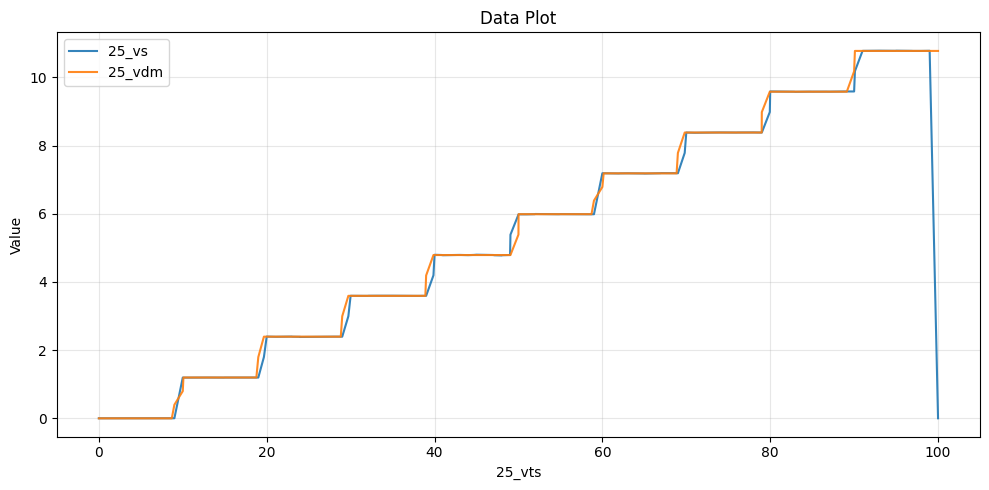

In [4]:
def merge_and_interpolate(df1, df2, time_col1 ="t1", time_col2="t2", offset = 0):
    """
    Merge two DataFrames on a unified time axis and linearly interpolate missing values.

    Parameters
    ----------
    df1, df2 : pd.DataFrame
        DataFrames containing a common time column.
    time_col : str
        Column name representing time.

    Returns
    -------
    merged_df : pd.DataFrame
        Combined DataFrame with unified timestamps and interpolated values.
    """
    df1 =df1.dropna()
    df2 = df2.dropna()
    tempdf1 = df1.copy()
    tempdf1[time_col1] = tempdf1[time_col1] + offset
    

    # 1. Create the union of all unique timestamps
    all_times = pd.Index(sorted(set(tempdf1[time_col1]) | set(df2[time_col2])))
    all_times = all_times[~all_times.duplicated(keep='first')]

    # 2. Reindex each dataframe on the union of times
    df1r = tempdf1.set_index(time_col1).reindex(all_times)
    df2r = df2.set_index(time_col2).reindex(all_times)

    # 3. Combine them
    merged = pd.concat([df1r, df2r], axis=1)

    # 4. Interpolate linearly along time
    merged = merged.interpolate(method="linear")

    # 5. Restore the timestamp column
    merged.index.name = time_col1
    merged = merged.reset_index()

    return merged

test_df = merge_and_interpolate(validation_df[["25_vs", "25_vts"]],validation_df[["25_vdm", "25_vtdm"]], "25_vts", "25_vtdm", validation_df["25_v_offset"][0] )
print(test_df.columns)
plot_columns(test_df, ["25_vs", "25_vdm"], x_col="25_vts")


In [6]:
print(validation_df.columns)

Index(['25_vs', '25_vts', '25_vdm', '25_vtdm', '25_v_offset', '25_cs',
       '25_cts', '25_cdm', '25_ctdm', '25_c_offset', '23_vs', '23_vts',
       '23_vdm', '23_vtdm', '23_v_offset', '23_cs', '23_cts', '23_cdm',
       '23_ctdm', '23_c_offset', '22_vts', '22_vtdm', '22_vdm', '22_vs',
       '22_v_offset', '22_cts', '22_ctdm', '22_cdm', '22_cs', '22_c_offset',
       '21_vts', '21_vtdm', '21_vdm', '21_vs', '21_v_offset', '21_cts',
       '21_ctdm', '21_cdm', '21_cs', '21_c_offset', '20_vts', '20_vtdm',
       '20_vdm', '20_vs', '20_v_offset', '20_cts', '20_ctdm', '20_cdm',
       '20_cs', '20_c_offset'],
      dtype='object')


In [8]:
import scipy.stats as stats
import numpy as np

def mean_absolute_error(df, col_1="1", col_2="2"):
    """
    Compute Mean absolute error.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing both columns.
    col_1 : str
        First variable (e.g. CPU total power).
    col_2 : str
        Second variable (e.g. RAPL or measured power).

    Returns
    -------
    dict
        MAE.
    """
    # Drop missing values
    data = df[[col_1, col_2]].dropna()

    x = data[col_1].to_numpy()
    y = data[col_2].to_numpy()



    mae = np.mean(np.abs(x - y))

    results = {
        "mae": mae
    }

    print(f"mae = {mae}")
    print(f"Samples used: {len(data)}")

    return results

In [17]:
#computes MAE for all metric class and datasets.
# also compute MAE, MAE derived precision for mean and worst case.
sensors_list = [20,21,22,23,25]
metrics_list = ['v', 'c']
result_dict = dict()
result_dict['v'] = []
result_dict['c'] = []
info_dict = dict()
info_dict['v'] = []
info_dict['c'] = []
for sensor in sensors_list: 
    for metric in metrics_list:
        experiment_df = merge_and_interpolate(
            validation_df[[f"{sensor}_{metric}s", f"{sensor}_{metric}ts"]],
            validation_df[[f"{sensor}_{metric}dm", f"{sensor}_{metric}tdm"]],
            f"{sensor}_{metric}ts",
            f"{sensor}_{metric}tdm",
            validation_df[f"{sensor}_{metric}_offset"][0] )
        info_dict[metric].append(experiment_df[f"{sensor}_{metric}dm"].max()) # store the max for the dmm for computing accuracy later
        #plot_columns(experiment_df, [f"{sensor}_{metric}s",f"{sensor}_{metric}dm"], x_col= f"{sensor}_{metric}ts")
        print(f"{sensor}_{metric}s vs {sensor}_{metric}dm correlation (non parametric)")
        result = mean_absolute_error(experiment_df, col_1=f"{sensor}_{metric}s", col_2=f"{sensor}_{metric}dm")
        print("----------------------------")
        result_dict[metric].append(result)
        print(result_dict)

grand_mae = 0
for metric in metrics_list:
    for result in result_dict[metric]: 
        grand_mae += result["mae"]
    print(f"Grand MAE for metric {metric}: {grand_mae / len(result_dict[metric])}")
    grand_mae = 0

df_mae_result = pd.concat({k: pd.DataFrame(v) for k, v in result_dict.items()}, axis=1)
print(df_mae_result)

df_mae_info = pd.concat({k: pd.DataFrame(v) for k, v in info_dict.items()}, axis=1)
print(df_mae_info)

for metric in metrics_list: 
    print(f"metric: {metric}")
    print(f"precision (average) (MAE / max) = {df_mae_result[metric]["mae"].mean() / df_mae_info[metric][0].mean()}") 
    print(f"precision (worst) (MAE / max) = {df_mae_result[metric]["mae"].max() / df_mae_info[metric][0].mean()}") 


20_vs vs 20_vdm correlation (non parametric)
mae = 0.12846574333333335
Samples used: 200
----------------------------
{'v': [{'mae': np.float64(0.12846574333333335)}], 'c': []}
20_cs vs 20_cdm correlation (non parametric)
mae = 0.003934780718390807
Samples used: 174
----------------------------
{'v': [{'mae': np.float64(0.12846574333333335)}], 'c': [{'mae': np.float64(0.003934780718390807)}]}
21_vs vs 21_vdm correlation (non parametric)
mae = 0.05681134887152786
Samples used: 192
----------------------------
{'v': [{'mae': np.float64(0.12846574333333335)}, {'mae': np.float64(0.05681134887152786)}], 'c': [{'mae': np.float64(0.003934780718390807)}]}
21_cs vs 21_cdm correlation (non parametric)
mae = 0.003910041060263658
Samples used: 177
----------------------------
{'v': [{'mae': np.float64(0.12846574333333335)}, {'mae': np.float64(0.05681134887152786)}], 'c': [{'mae': np.float64(0.003934780718390807)}, {'mae': np.float64(0.003910041060263658)}]}
22_vs vs 22_vdm correlation (non paramet

In [8]:
import scipy.stats as stats
import numpy as np

def nonparametric_correlation(df, col_1="1", col_2="2"):
    """
    Compute non-parametric correlation between two columns (Spearman and Kendall).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing both columns.
    col_1 : str
        First variable (e.g. CPU total power).
    col_2 : str
        Second variable (e.g. RAPL or measured power).

    Returns
    -------
    dict
        Spearman and Kendall correlation results.
    """
    # Drop missing values
    data = df[[col_1, col_2]].dropna()

    x = data[col_1].to_numpy()
    y = data[col_2].to_numpy()

    # Spearman rank correlation (monotonic relationship)
    spearman_rho, spearman_p = stats.spearmanr(x, y)

    # Kendall Tau correlation (ordinal consistency)
    kendall_tau, kendall_p = stats.kendalltau(x, y)

    results = {
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "kendall_tau": kendall_tau,
        "kendall_p": kendall_p,
        "n": len(data)
    }

    print(f"Spearman ρ = {spearman_rho:.4f} (p = {spearman_p:.3e})")
    print(f"Kendall τ = {kendall_tau:.4f} (p = {kendall_p:.3e})")
    print(f"Samples used: {len(data)}")

    return results

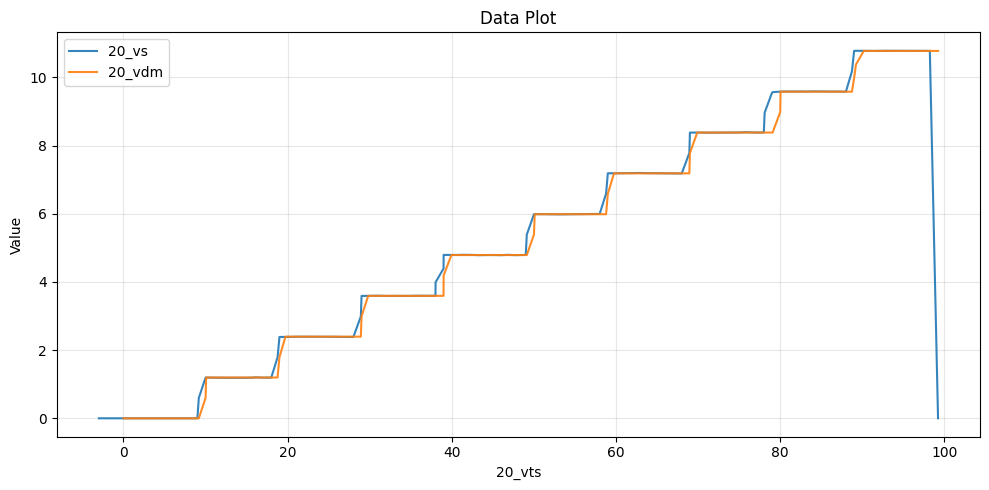

20_vs vs 20_vdm correlation (non parametric)
Spearman ρ = 0.9699 (p = 1.678e-123)
Kendall τ = 0.9276 (p = 3.995e-79)
Samples used: 200
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}], 'c': []}


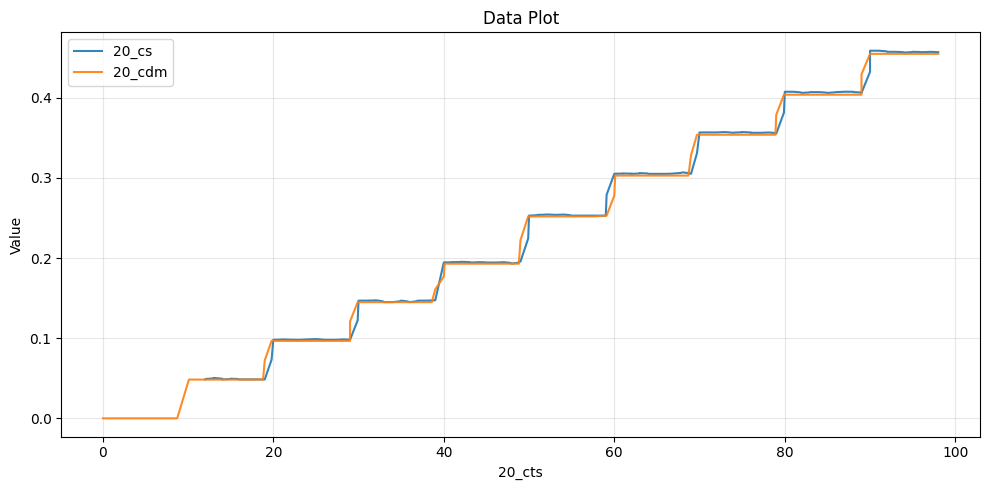

20_cs vs 20_cdm correlation (non parametric)
Spearman ρ = 0.9930 (p = 2.634e-161)
Kendall τ = 0.9462 (p = 2.125e-69)
Samples used: 174
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}], 'c': [{'spearman_rho': np.float64(0.9929626622101305), 'spearman_p': np.float64(2.6340640623902383e-161), 'kendall_tau': np.float64(0.946246745215512), 'kendall_p': np.float64(2.1247087782847683e-69), 'n': 174}]}


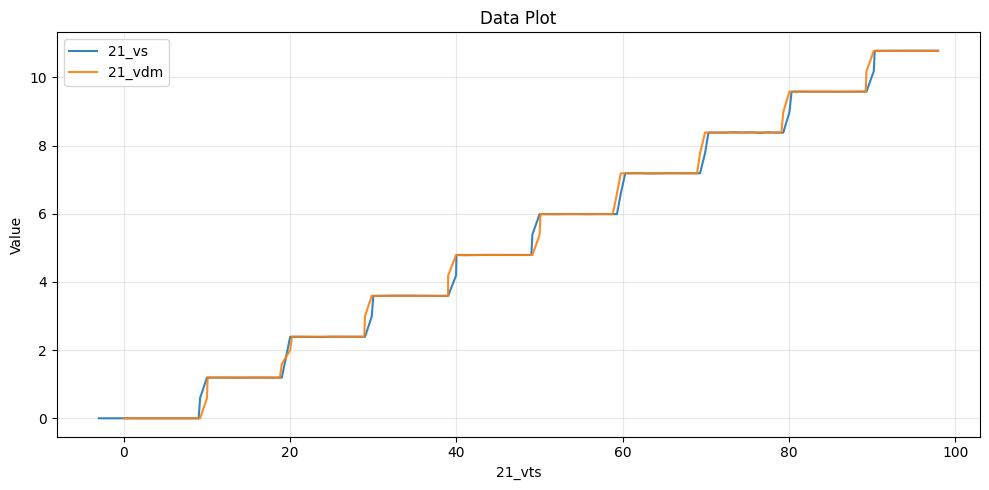

21_vs vs 21_vdm correlation (non parametric)
Spearman ρ = 0.9946 (p = 2.814e-189)
Kendall τ = 0.9553 (p = 1.637e-79)
Samples used: 192
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}, {'spearman_rho': np.float64(0.9946494732723106), 'spearman_p': np.float64(2.813806284606654e-189), 'kendall_tau': np.float64(0.955333458062662), 'kendall_p': np.float64(1.6371742857689875e-79), 'n': 192}], 'c': [{'spearman_rho': np.float64(0.9929626622101305), 'spearman_p': np.float64(2.6340640623902383e-161), 'kendall_tau': np.float64(0.946246745215512), 'kendall_p': np.float64(2.1247087782847683e-69), 'n': 174}]}


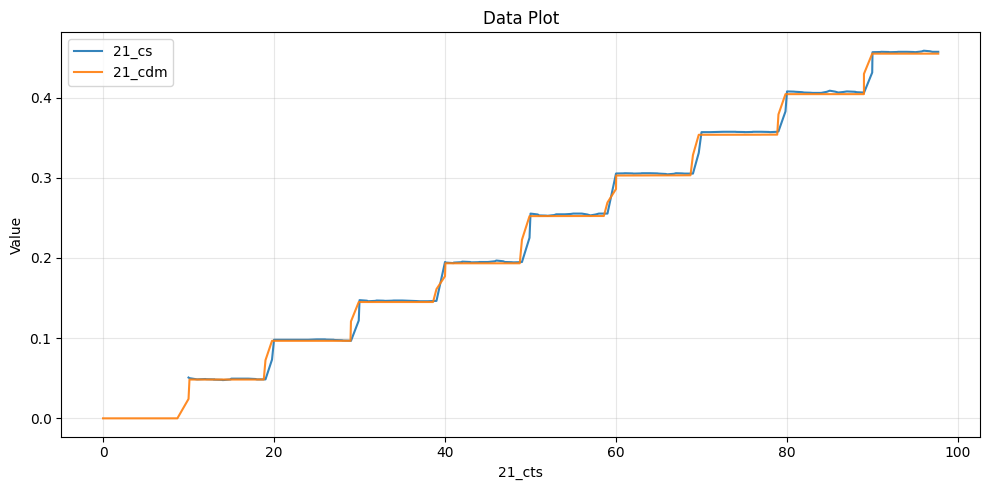

21_cs vs 21_cdm correlation (non parametric)
Spearman ρ = 0.9911 (p = 2.215e-155)
Kendall τ = 0.9323 (p = 3.349e-70)
Samples used: 177
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}, {'spearman_rho': np.float64(0.9946494732723106), 'spearman_p': np.float64(2.813806284606654e-189), 'kendall_tau': np.float64(0.955333458062662), 'kendall_p': np.float64(1.6371742857689875e-79), 'n': 192}], 'c': [{'spearman_rho': np.float64(0.9929626622101305), 'spearman_p': np.float64(2.6340640623902383e-161), 'kendall_tau': np.float64(0.946246745215512), 'kendall_p': np.float64(2.1247087782847683e-69), 'n': 174}, {'spearman_rho': np.float64(0.9911423847087572), 'spearman_p': np.float64(2.214595897267789e-155), 'kendall_tau': np.float64(0.9322711807558676), 'kendall_p': np.float64(3.3487721428915296e-70), 'n': 177}]}

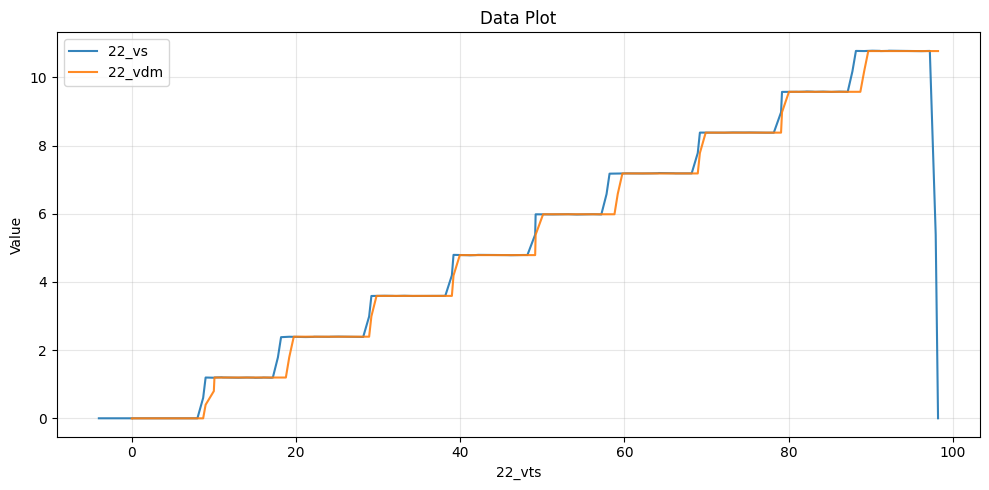

22_vs vs 22_vdm correlation (non parametric)
Spearman ρ = 0.9590 (p = 7.892e-110)
Kendall τ = 0.9123 (p = 3.268e-76)
Samples used: 199
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}, {'spearman_rho': np.float64(0.9946494732723106), 'spearman_p': np.float64(2.813806284606654e-189), 'kendall_tau': np.float64(0.955333458062662), 'kendall_p': np.float64(1.6371742857689875e-79), 'n': 192}, {'spearman_rho': np.float64(0.9589995660208853), 'spearman_p': np.float64(7.892092486730977e-110), 'kendall_tau': np.float64(0.9122628829895431), 'kendall_p': np.float64(3.267737505641174e-76), 'n': 199}], 'c': [{'spearman_rho': np.float64(0.9929626622101305), 'spearman_p': np.float64(2.6340640623902383e-161), 'kendall_tau': np.float64(0.946246745215512), 'kendall_p': np.float64(2.1247087782847683e-69), 'n': 174}, {

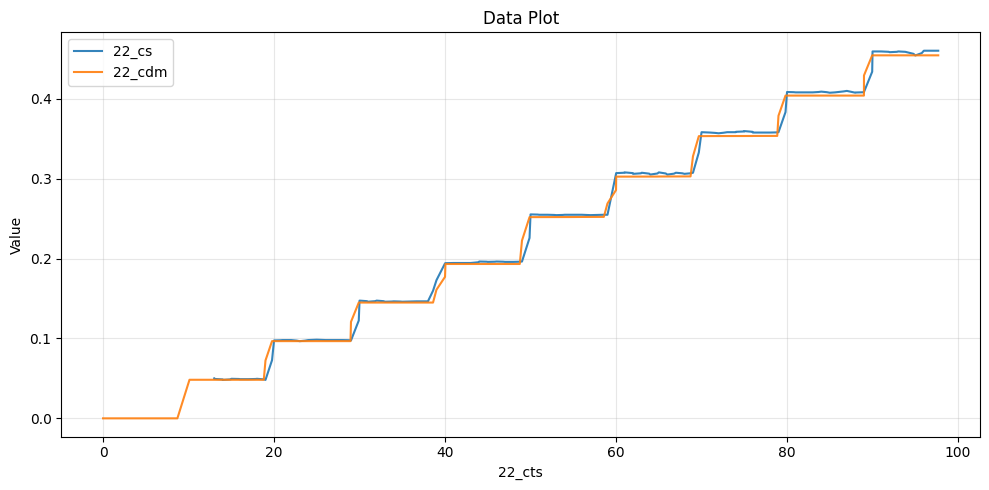

22_cs vs 22_cdm correlation (non parametric)
Spearman ρ = 0.9913 (p = 1.046e-150)
Kendall τ = 0.9330 (p = 3.266e-68)
Samples used: 171
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}, {'spearman_rho': np.float64(0.9946494732723106), 'spearman_p': np.float64(2.813806284606654e-189), 'kendall_tau': np.float64(0.955333458062662), 'kendall_p': np.float64(1.6371742857689875e-79), 'n': 192}, {'spearman_rho': np.float64(0.9589995660208853), 'spearman_p': np.float64(7.892092486730977e-110), 'kendall_tau': np.float64(0.9122628829895431), 'kendall_p': np.float64(3.267737505641174e-76), 'n': 199}], 'c': [{'spearman_rho': np.float64(0.9929626622101305), 'spearman_p': np.float64(2.6340640623902383e-161), 'kendall_tau': np.float64(0.946246745215512), 'kendall_p': np.float64(2.1247087782847683e-69), 'n': 174}, {

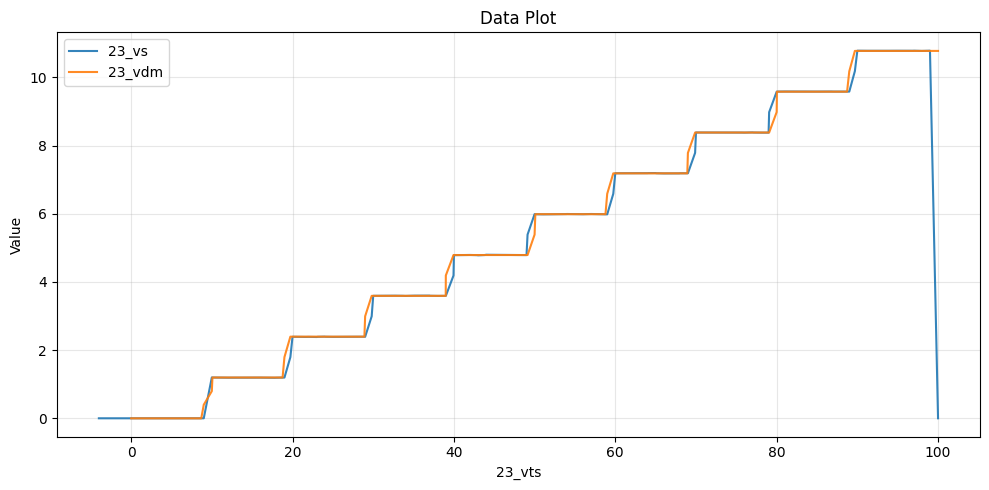

23_vs vs 23_vdm correlation (non parametric)
Spearman ρ = 0.9691 (p = 2.371e-122)
Kendall τ = 0.9285 (p = 2.113e-79)
Samples used: 200
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}, {'spearman_rho': np.float64(0.9946494732723106), 'spearman_p': np.float64(2.813806284606654e-189), 'kendall_tau': np.float64(0.955333458062662), 'kendall_p': np.float64(1.6371742857689875e-79), 'n': 192}, {'spearman_rho': np.float64(0.9589995660208853), 'spearman_p': np.float64(7.892092486730977e-110), 'kendall_tau': np.float64(0.9122628829895431), 'kendall_p': np.float64(3.267737505641174e-76), 'n': 199}, {'spearman_rho': np.float64(0.9691219428626247), 'spearman_p': np.float64(2.3706938377464996e-122), 'kendall_tau': np.float64(0.9285370446319954), 'kendall_p': np.float64(2.1131123737702887e-79), 'n': 200}], 'c': [

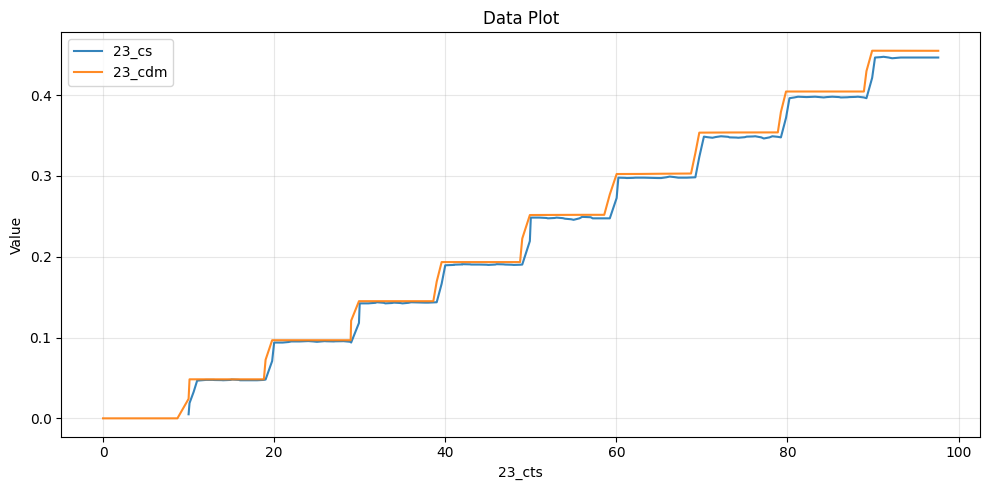

23_cs vs 23_cdm correlation (non parametric)
Spearman ρ = 0.9923 (p = 3.702e-158)
Kendall τ = 0.9378 (p = 3.254e-70)
Samples used: 174
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}, {'spearman_rho': np.float64(0.9946494732723106), 'spearman_p': np.float64(2.813806284606654e-189), 'kendall_tau': np.float64(0.955333458062662), 'kendall_p': np.float64(1.6371742857689875e-79), 'n': 192}, {'spearman_rho': np.float64(0.9589995660208853), 'spearman_p': np.float64(7.892092486730977e-110), 'kendall_tau': np.float64(0.9122628829895431), 'kendall_p': np.float64(3.267737505641174e-76), 'n': 199}, {'spearman_rho': np.float64(0.9691219428626247), 'spearman_p': np.float64(2.3706938377464996e-122), 'kendall_tau': np.float64(0.9285370446319954), 'kendall_p': np.float64(2.1131123737702887e-79), 'n': 200}], 'c': [

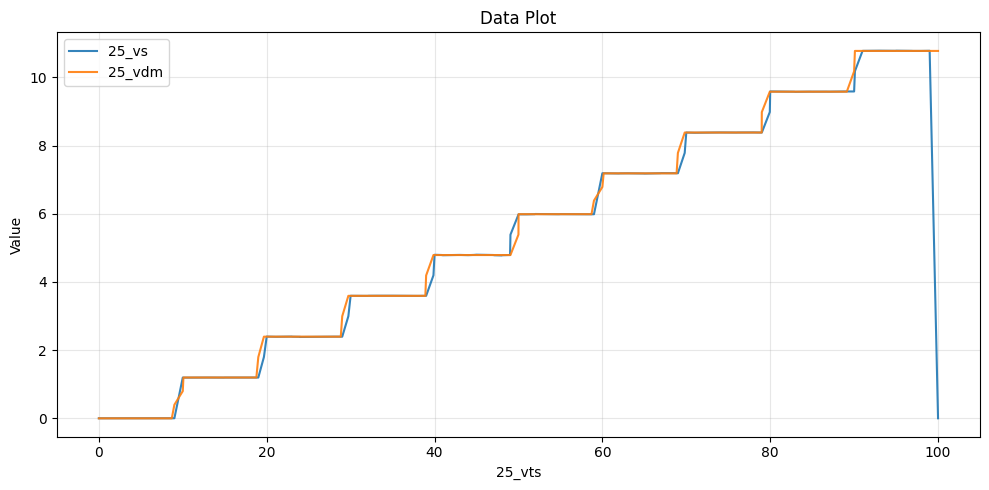

25_vs vs 25_vdm correlation (non parametric)
Spearman ρ = 0.9677 (p = 6.977e-120)
Kendall τ = 0.9258 (p = 1.147e-78)
Samples used: 199
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}, {'spearman_rho': np.float64(0.9946494732723106), 'spearman_p': np.float64(2.813806284606654e-189), 'kendall_tau': np.float64(0.955333458062662), 'kendall_p': np.float64(1.6371742857689875e-79), 'n': 192}, {'spearman_rho': np.float64(0.9589995660208853), 'spearman_p': np.float64(7.892092486730977e-110), 'kendall_tau': np.float64(0.9122628829895431), 'kendall_p': np.float64(3.267737505641174e-76), 'n': 199}, {'spearman_rho': np.float64(0.9691219428626247), 'spearman_p': np.float64(2.3706938377464996e-122), 'kendall_tau': np.float64(0.9285370446319954), 'kendall_p': np.float64(2.1131123737702887e-79), 'n': 200}, {'spear

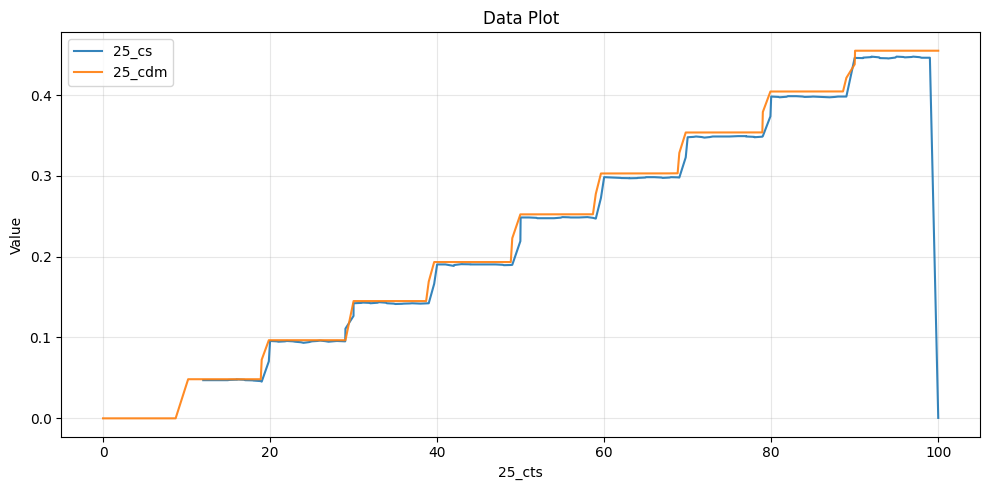

25_cs vs 25_cdm correlation (non parametric)
Spearman ρ = 0.9622 (p = 1.153e-99)
Kendall τ = 0.9213 (p = 7.829e-68)
Samples used: 175
----------------------------
{'v': [{'spearman_rho': np.float64(0.9699493532765383), 'spearman_p': np.float64(1.6778495432831865e-123), 'kendall_tau': np.float64(0.927629048299639), 'kendall_p': np.float64(3.995370018602254e-79), 'n': 200}, {'spearman_rho': np.float64(0.9946494732723106), 'spearman_p': np.float64(2.813806284606654e-189), 'kendall_tau': np.float64(0.955333458062662), 'kendall_p': np.float64(1.6371742857689875e-79), 'n': 192}, {'spearman_rho': np.float64(0.9589995660208853), 'spearman_p': np.float64(7.892092486730977e-110), 'kendall_tau': np.float64(0.9122628829895431), 'kendall_p': np.float64(3.267737505641174e-76), 'n': 199}, {'spearman_rho': np.float64(0.9691219428626247), 'spearman_p': np.float64(2.3706938377464996e-122), 'kendall_tau': np.float64(0.9285370446319954), 'kendall_p': np.float64(2.1131123737702887e-79), 'n': 200}, {'spearm

In [ ]:
sensors_list = [20,21,22,23,25]
metrics_list = ['v', 'c']
result_dict = dict()
result_dict['v'] = []
result_dict['c'] = []
for sensor in sensors_list: 
    for metric in metrics_list:
        experiment_df = merge_and_interpolate(
            validation_df[[f"{sensor}_{metric}s", f"{sensor}_{metric}ts"]],
            validation_df[[f"{sensor}_{metric}dm", f"{sensor}_{metric}tdm"]],
            f"{sensor}_{metric}ts",
            f"{sensor}_{metric}tdm",
            validation_df[f"{sensor}_{metric}_offset"][0] )
        plot_columns(experiment_df, [f"{sensor}_{metric}s",f"{sensor}_{metric}dm"], x_col= f"{sensor}_{metric}ts")
        print(f"{sensor}_{metric}s vs {sensor}_{metric}dm correlation (non parametric)")
        result = nonparametric_correlation(experiment_df, col_1=f"{sensor}_{metric}s", col_2=f"{sensor}_{metric}dm")
        print("----------------------------")
        result_dict[metric].append(result)
        print(result_dict)
                

In [10]:
# bootstrapping
import numpy as np
from sklearn.utils import resample


for metric in metrics_list: 
    results_list = result_dict[metric]
    rhos = []
    for result in results_list:
        if (result["spearman_p"] < 0.05):
            rhos.append(result["spearman_rho"])

    corrs = np.array(rhos)  

    boot_means = [np.mean(resample(corrs)) for _ in range(10000)]
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    print(f"Mean correlation = {corrs.mean():.4f}, 95% CI = [{ci_low:.4f}, {ci_high:.4f}]")

for metric in metrics_list: 
    results_list = result_dict[metric]
    rhos = []
    for result in results_list:
        
        rhos.append(result["spearman_p"])

    corrs = np.array(rhos)  

    boot_means = [np.mean(resample(corrs)) for _ in range(10000)]
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    print(f"Mean p = {corrs.mean():.4f}, 95% CI = [{ci_low:.4f}, {ci_high:.4f}]")

Mean correlation = 0.9721, 95% CI = [0.9632, 0.9843]
Mean correlation = 0.9860, 95% CI = [0.9740, 0.9925]
Mean p = 0.0000, 95% CI = [0.0000, 0.0000]
Mean p = 0.0000, 95% CI = [0.0000, 0.0000]


In [11]:
import numpy as np
import pandas as pd

def bland_altman(x, y):
    """
    Compute Bland–Altman statistics for two time-series measurements.
    
    Parameters
    ----------
    x : array-like
        First measurement series.
    y : array-like
        Second measurement series. Must match length of x.

    Returns
    -------
    df : pandas.DataFrame
        DataFrame containing mean and difference for each sample.
    stats : dict
        Dictionary containing bias, SD, LoA upper/lower, etc.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Compute Bland–Altman components
    mean_vals = (x + y) / 2
    diff_vals = x - y

    bias = np.mean(diff_vals)
    sd = np.std(diff_vals, ddof=1)  # use sample SD

    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    df = pd.DataFrame({
        'mean': mean_vals,
        'difference': diff_vals
    })

    stats = {
        'bias': bias,
        'sd': sd,
        'loa_upper': loa_upper,
        'loa_lower': loa_lower,
        'n': len(x)
    }

    return df, stats

# df_ba, stats = bland_altman(sensor1, sensor2)

# print("Bias:", stats['bias'])
# print("Upper LoA:", stats['loa_upper'])
# print("Lower LoA:", stats['loa_lower'])



In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def bland_altman_plot(method1, method2, title="Bland–Altman Plot", regression=True):
    """
    method1: np.array or pd.Series
    method2: np.array or pd.Series
    regression: include proportional bias regression line
    """

    method1 = np.asarray(method1)
    method2 = np.asarray(method2)

    # Mean and difference
    mean_vals = (method1 + method2) / 2
    diff_vals = method1 - method2

    # Statistics
    bias = np.mean(diff_vals)
    sd = np.std(diff_vals, ddof=1)
    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    # --- Plot ---
    plt.figure(figsize=(8,5))
    plt.scatter(mean_vals, diff_vals, s=2, alpha=0.6)
    plt.axhline(bias, color='red', linestyle='--', label=f'Bias = {bias:.3f}')
    plt.axhline(loa_upper, color='grey', linestyle='--', label=f'+1.96 SD = {loa_upper:.3f}')
    plt.axhline(loa_lower, color='grey', linestyle='--', label=f'-1.96 SD = {loa_lower:.3f}')

    # Optional proportional bias regression
    if regression:
        slope, intercept, r, p, _ = stats.linregress(mean_vals, diff_vals)
        x = np.linspace(mean_vals.min(), mean_vals.max(), 200)
        plt.plot(x, intercept + slope*x, color='green',
                 label=f'Regression: slope={slope:.4f}, p={p:.3g}')

    plt.xlabel("Mean of Methods")
    plt.ylabel("Difference (Method1 − Method2)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    # Return useful values
    return {
        "bias": bias,
        "sd": sd,
        "loa_lower": loa_lower,
        "loa_upper": loa_upper,
        "regression_slope": slope if regression else None,
        "regression_p": p if regression else None
    }



AttributeError: 'dict' object has no attribute 'linregress'

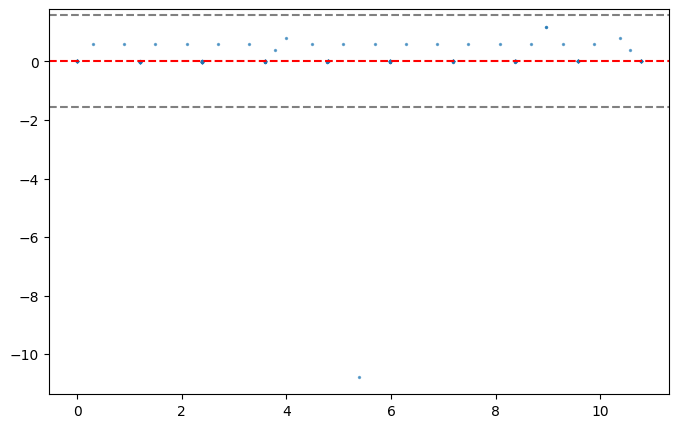

In [13]:
from pprint import pprint

sensors_list = [20,21,22,23,25]
metrics_list = ['v', 'c']
result_dict_ba = dict()
result_dict_ba['v'] = []
result_dict_ba['c'] = []
for sensor in sensors_list: 
    for metric in metrics_list:
        experiment_df = merge_and_interpolate(
            validation_df[[f"{sensor}_{metric}s", f"{sensor}_{metric}ts"]],
            validation_df[[f"{sensor}_{metric}dm", f"{sensor}_{metric}tdm"]],
            f"{sensor}_{metric}ts",
            f"{sensor}_{metric}tdm",
            validation_df[f"{sensor}_{metric}_offset"][0] )
        #plot_columns(experiment_df, [f"{sensor}_{metric}s",f"{sensor}_{metric}dm"], x_col= f"{sensor}_{metric}ts")
        experiment_df = experiment_df.dropna()
        df_ba, stats = bland_altman(experiment_df[f"{sensor}_{metric}s"], experiment_df[f"{sensor}_{metric}dm"])
        bland_altman_plot(experiment_df[f"{sensor}_{metric}s"], experiment_df[f"{sensor}_{metric}dm"])
        slope = np.polyfit(df_ba['mean'], df_ba['difference'], 1)[0]
        print(f"slope={slope}")
        print(f"{sensor}_{metric}s vs {sensor}_{metric}dm bland altman")
        print("----------------------------")
        result_dict_ba[metric].append(stats)
pprint(result_dict_ba)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def bland_altman_plot(method1, method2, title="Bland–Altman Plot", regression=True):
    """
    method1: np.array or pd.Series
    method2: np.array or pd.Series
    regression: include proportional bias regression line
    """

    method1 = np.asarray(method1)
    method2 = np.asarray(method2)

    # Mean and difference
    mean_vals = (method1 + method2) / 2
    diff_vals = method1 - method2

    # Statistics
    bias = np.mean(diff_vals)
    sd = np.std(diff_vals, ddof=1)
    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    # --- Plot ---
    plt.figure(figsize=(8,5))
    plt.scatter(mean_vals, diff_vals, s=2, alpha=0.6)
    plt.axhline(bias, color='red', linestyle='--', label=f'Bias = {bias:.3f}')
    plt.axhline(loa_upper, color='grey', linestyle='--', label=f'+1.96 SD = {loa_upper:.3f}')
    plt.axhline(loa_lower, color='grey', linestyle='--', label=f'-1.96 SD = {loa_lower:.3f}')

    # Optional proportional bias regression
    if regression:
        slope, intercept, r, p, _ = stats.linregress(mean_vals, diff_vals)
        x = np.linspace(mean_vals.min(), mean_vals.max(), 200)
        plt.plot(x, intercept + slope*x, color='green',
                 label=f'Regression: slope={slope:.4f}, p={p:.3g}')

    plt.xlabel("Mean of Methods")
    plt.ylabel("Difference (Method1 − Method2)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    # Return useful values
    return {
        "bias": bias,
        "sd": sd,
        "loa_lower": loa_lower,
        "loa_upper": loa_upper,
        "regression_slope": slope if regression else None,
        "regression_p": p if regression else None
    }



NameError: name 'interpolate_df' is not defined